In [1]:
import os
from time import sleep
from tqdm import tqdm

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed
from keras import regularizers

from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

C:\Users\nicho\AppData\Local\Temp\ipykernel_18072\1763472020.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
base_path = '/Users/nicholastey/Desktop/thesis/gnss_spoof_detector/spoof_detector/data/'
base_path = 'C:/Users/nicho/Desktop/gnss_spoof_detector/spoof_detector/data'

In [3]:
cs_path, ds1_path, ds3_path, ds2_path, ds4_path, ds7_path, ds8_path = [os.path.join(base_path, ds_path) for ds_path in os.listdir(base_path)]


In [4]:
columns = ['channel', 'prn', 'acq_doopler_hz', 'acq_doppler_step', 'fs', 'prompt_i', 'prompt_q', 'cn0_db_hz', 'carrier_doppler_hz', 'pseudorange_m', 'rx_time']

for ds_fname in os.listdir(base_path):
  tmp_path = os.path.join(base_path, ds_fname)
  key = ds_fname.split('.')[0]
  
  tmp_df = pd.read_csv(tmp_path, header=None)
  prn_li = []
  for i in range(8):
    prn_li.append(int(tmp_df.iloc[1, 11*i+1]))
  globals()[f'{key}_dict'] = {
      int(f'{prn_li[0]}') : tmp_df.iloc[100:, 0:9].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[1]}') : tmp_df.iloc[100:, 11:20].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[2]}') : tmp_df.iloc[100:, 22:31].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[3]}') : tmp_df.iloc[100:, 33:42].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[4]}') : tmp_df.iloc[100:, 44:53].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[5]}') : tmp_df.iloc[100:, 55:64].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[6]}') : tmp_df.iloc[100:, 66:75].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      int(f'{prn_li[7]}') : tmp_df.iloc[100:, 77:86].rename(columns=lambda x: columns[x%11]).iloc[:, 5:].fillna(0),
      'prn' : prn_li
  }

dicts = [cs_dict, ds1_dict, ds2_dict, ds3_dict, ds4_dict, ds7_dict, ds8_dict]

In [8]:
big_df = []

dicts_with_labels = [
    (cs_dict, 0),  # Clean
    (ds1_dict, 1),
    (ds2_dict, 2),
    (ds3_dict, 3),
    (ds4_dict, 4),
    (ds7_dict, 5),
    (ds8_dict, 6)
]

for dataset, label in dicts_with_labels:
    for prn in dataset['prn']:
        df = dataset[prn].copy()
        df['spoofed'] = label
        df['prn'] = prn
        big_df.append(df)

big_df = pd.concat(big_df, ignore_index=True)
# print(big_df.shape)
# print(big_df.columns)
# print(big_df['spoofed'].value_counts(normalize=True))

# big_df

In [9]:
big_df.head()

,prompt_i,prompt_q,cn0_db_hz,carrier_doppler_hz,spoofed,prn
0,-121029744.0,12634.414062,49.919094,1812.98621,0,13
1,-121029744.0,12634.414062,49.919094,1812.98621,0,13
2,-121029744.0,12634.414062,49.919094,1812.98621,0,13
3,-121029744.0,12634.414062,49.919094,1812.98621,0,13
4,-121029744.0,12634.414062,49.919094,1812.98621,0,13


In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# 0) Helper(s)
# --------------------------------------------
def _rolling_slope(y: np.ndarray) -> float:
    n = len(y)
    if n < 2:
        return np.nan
    x = np.arange(n, dtype=float)
    x = x - x.mean()
    y = y.astype(float)
    # robust to NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    x = x[mask]; y = y[mask]
    denom = np.dot(x, x)
    if denom == 0:
        return 0.0
    return float(np.dot(x, y - y.mean()) / denom)

def add_iq_drift_features(df: pd.DataFrame, window: int = 128, eps: float = 1e-9) -> pd.DataFrame:
    """
    Adds drift-sensitive features in the complex plane z = I + jQ,
    ordered by 'seq' within each (sample_id, prn).
    Required cols: prompt_i, prompt_q, sample_id, prn, seq
    """
    required = {'prompt_i','prompt_q','sample_id','prn','seq'}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns for drift features: {missing}")

    out = df.sort_values(['sample_id','prn','seq']).copy()

    # Base polar quantities
    out['mag'] = np.hypot(out['prompt_i'], out['prompt_q'])

    # Phase (unwrapped) per group
    def _unwrap_phase(g):
        ph = np.arctan2(g['prompt_q'].to_numpy(), g['prompt_i'].to_numpy())
        return pd.Series(np.unwrap(ph), index=g.index)

    out['phase'] = out.groupby(['sample_id','prn'], sort=False).apply(_unwrap_phase)\
                      .reset_index(level=[0,1], drop=True)

    # Phase increment
    out['dphase'] = out.groupby(['sample_id','prn'], sort=False)['phase']\
                       .diff().fillna(0.0)

    # Step-wise path length in complex plane
    dI = out.groupby(['sample_id','prn'], sort=False)['prompt_i'].diff()
    dQ = out.groupby(['sample_id','prn'], sort=False)['prompt_q'].diff()
    step_len = np.hypot(dI, dQ).fillna(0.0)

    out['pathlen_w'] = step_len.groupby([out['sample_id'], out['prn']], sort=False)\
                               .rolling(window, min_periods=2).sum()\
                               .reset_index(level=[0,1], drop=True)

    # Net displacement over window
    I_lag = out.groupby(['sample_id','prn'], sort=False)['prompt_i'].shift(window-1)
    Q_lag = out.groupby(['sample_id','prn'], sort=False)['prompt_q'].shift(window-1)
    out['net_disp_w'] = np.hypot(out['prompt_i'] - I_lag,
                                 out['prompt_q'] - Q_lag)

    # Tortuosity
    out['tortuosity_w'] = out['pathlen_w'] / (out['net_disp_w'] + eps)

    # Rolling stats of dphase
    out['dphase_mean_w'] = out.groupby(['sample_id','prn'], sort=False)['dphase']\
                              .rolling(window, min_periods=5).mean()\
                              .reset_index(level=[0,1], drop=True)

    out['dphase_std_w'] = out.groupby(['sample_id','prn'], sort=False)['dphase']\
                             .rolling(window, min_periods=5).std()\
                             .reset_index(level=[0,1], drop=True)

    # Rolling slopes (linear regression slope over window)
    def _rolling_slope(y: np.ndarray) -> float:
        n = len(y)
        if n < 2:
            return np.nan
        x = np.arange(n, dtype=float)
        x = x - x.mean()
        y = y.astype(float)
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 2:
            return np.nan
        x = x[mask]; y = y[mask]
        denom = np.dot(x, x)
        if denom == 0:
            return 0.0
        return float(np.dot(x, y - y.mean()) / denom)

    out['phase_slope_w'] = out.groupby(['sample_id','prn'], sort=False)['phase']\
                              .rolling(window, min_periods=5)\
                              .apply(_rolling_slope, raw=True)\
                              .reset_index(level=[0,1], drop=True)

    out['mag_slope_w'] = out.groupby(['sample_id','prn'], sort=False)['mag']\
                            .rolling(window, min_periods=5)\
                            .apply(_rolling_slope, raw=True)\
                            .reset_index(level=[0,1], drop=True)

    # Covariance ellipse anisotropy
    def _ellipse_ratio_group(g):
        I = g['prompt_i'].to_numpy()
        Q = g['prompt_q'].to_numpy()
        n = len(g)
        out_arr = np.full(n, np.nan, dtype=float)
        if n < 5:
            return pd.Series(out_arr, index=g.index)
        for t in range(n):
            s = max(0, t - (window - 1))
            m = t - s + 1
            if m < 5:
                continue
            Ii = I[s:t+1]
            Qi = Q[s:t+1]
            C = np.cov(np.vstack([Ii, Qi]))
            if not np.isfinite(C).all():
                continue
            vals = np.linalg.eigvalsh(C)
            if vals[0] <= 0 or vals[1] <= 0:
                continue
            out_arr[t] = float(vals[1] / vals[0])
        return pd.Series(out_arr, index=g.index)

    out['ellipse_ratio_w'] = out.groupby(['sample_id','prn'], sort=False)\
                                .apply(_ellipse_ratio_group)\
                                .reset_index(level=[0,1], drop=True)

    return out


# --------------------------------------------
# 1) Build per-dict samples + skip head + seq = 1..N
# --------------------------------------------
def build_samples(dicts_with_labels, skip_head: int = 100):
    """
    Build per-scenario DFs, drop first `skip_head` rows per (sample_id, prn),
    then assign 1..N 'seq' as pseudo-time.
    """
    samples = []
    for sid, (dataset, label) in enumerate(dicts_with_labels):
        dfs = []
        for prn in dataset['prn']:
            g = dataset[prn].copy().reset_index(drop=True)

            # metadata
            g['sample_id'] = sid
            g['spoofed']   = label
            g['prn']       = prn

            # drop the first N rows for THIS (sid, prn)
            if skip_head > 0 and len(g) > 0:
                g = g.iloc[skip_head:, :]

            # pseudo-time AFTER trimming: 1..len(g)
            if len(g) > 0:
                g['seq'] = np.arange(1, len(g) + 1, dtype=np.int64)

            dfs.append(g)

        samples.append(pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame())
    return samples

# knob: how many early samples to ignore per (scenario, PRN)
SKIP_HEAD_PRN = 100

# -------------------------------------------------
# 1) Drop clean scenario, keep ds1, ds2, ds3, ds4, ds7, ds8
# dicts_with_labels = [clean, ds1, ds2, ds3, ds4, ds7, ds8]
# -------------------------------------------------
keep_idx = list(range(1, len(dicts_with_labels)))   # [1,2,3,4,5,6]
dicts_spoof = [dicts_with_labels[i] for i in keep_idx]

# After build_samples(dicts_spoof), sample_id mapping is:
#   0 -> ds1, 1 -> ds2, 2 -> ds3, 3 -> ds4, 4 -> ds7, 5 -> ds8
attr_map = {
    0: dict(time_push=0, pos_push=0, overpowered=0),  # ds1
    1: dict(time_push=1, pos_push=0, overpowered=1),  # ds2
    2: dict(time_push=1, pos_push=0, overpowered=0),  # ds3
    3: dict(time_push=0, pos_push=1, overpowered=0),  # ds4
    4: dict(time_push=1, pos_push=0, overpowered=0),  # ds7
    5: dict(time_push=1, pos_push=0, overpowered=0),  # ds8
}

SKIP_HEAD_PRN = 100
samples = build_samples(dicts_spoof, skip_head=SKIP_HEAD_PRN)

# -------------------------------------------------
# 2) Add drift-focused I/Q features (this makes mag, phase, etc.)
# -------------------------------------------------
DRIFT_WINDOW = 128
samples = [add_iq_drift_features(df, window=DRIFT_WINDOW) for df in samples]

# -------------------------------------------------
# 3) Add attribute columns (time_push, pos_push, overpowered)
# -------------------------------------------------
def add_attr_columns_per_sample(samples, attr_map):
    out = []
    for sid, df in enumerate(samples):
        df = df.copy()
        attrs = attr_map.get(sid, {})
        for k in ['time_push', 'pos_push', 'overpowered']:
            df[k] = attrs.get(k, 0)
        out.append(df)
    return out

samples = add_attr_columns_per_sample(samples, attr_map)

def make_sequences(df,
                   time_steps=200,
                   step=1,
                   feat_cols=None,
                   label_col='time_push'):
    """
    Convert per-row features into fixed-length sequences for LSTM/CNN/RNN models.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: feat_cols, label_col, sample_id, prn, seq
    time_steps : int
        Length of each sliding window sequence
    step : int
        Stride between consecutive windows
    feat_cols : list of str
        Which feature columns to use (scaled)
    label_col : str
        Which label to attach (e.g. time_push, pos_push, overpowered)
    
    Returns
    -------
    X : np.ndarray, shape = (num_windows, time_steps, num_features)
    y : np.ndarray, shape = (num_windows,)
    """

    if feat_cols is None:
        raise ValueError("feat_cols must be provided.")

    Xs, ys = [], []

    # enforce correct ordering
    df_sorted = df.sort_values(['sample_id', 'prn', 'seq'])

    # iterate over each PRN track
    for (_, _), g in df_sorted.groupby(['sample_id', 'prn'], sort=False):
        Xg = g[feat_cols].to_numpy()
        yg = g[label_col].to_numpy()
        n = len(g)

        if n < time_steps:
            continue

        for i in range(0, n - time_steps + 1, step):
            Xs.append(Xg[i : i + time_steps])
            ys.append(yg[i + time_steps - 1])  # label = last step in window

    return np.asarray(Xs), np.asarray(ys)


# -------------------------------------------------
# 4) Now concatenate ALL spoof samples -> df_all
#     (only now do mag/phase/etc exist)
# -------------------------------------------------
df_all = pd.concat(samples, ignore_index=True)

# -------------------------------------------------
# 5) Scaling (fit only on feature_cols)
# -------------------------------------------------
feature_cols = [
    'prompt_i','prompt_q','mag','phase','dphase',
    'pathlen_w','net_disp_w','tortuosity_w',
    'dphase_mean_w','dphase_std_w',
    'phase_slope_w','mag_slope_w','ellipse_ratio_w'
]

# at this point df_all must have all of these; you can check:
# print(df_all.columns)

scaler = StandardScaler().fit(df_all[feature_cols].values)

def scale_df(df):
    Xs = scaler.transform(df[feature_cols].values)
    Xs = pd.DataFrame(Xs, index=df.index, columns=feature_cols)
    return Xs.join(df[['spoofed','prn','sample_id','seq',
                       'time_push','pos_push','overpowered']])

df_all_s = scale_df(df_all)

TIME_STEPS = 100

# Build ALL windows first
X_all, y_all = make_sequences(df_all_s, time_steps=TIME_STEPS, feat_cols=feature_cols, label_col='time_push')

# Random window-level split
idx = np.arange(len(X_all))
np.random.seed(42)
np.random.shuffle(idx)

train_end = int(0.8 * len(idx))
val_end = int(0.9 * len(idx))

train_idx = idx[:train_end]
val_idx   = idx[train_end:val_end]
test_idx  = idx[val_end:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]



# X_tr, y_tr, X_va, y_va, X_te, y_te are now ready for your model


C:\Users\nicho\AppData\Local\Temp\ipykernel_7968\1111591945.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['phase'] = out.groupby(['sample_id','prn'], sort=False).apply(_unwrap_phase)\
C:\Users\nicho\AppData\Local\Temp\ipykernel_7968\1111591945.py:133: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_ellipse_ratio_group)\
C:\Users\nicho\AppData\Local\Temp\ipykernel_7968\1111591945.py:47: Depr

In [9]:
print("train classes:", np.unique(y_tr))
print("val classes:",   np.unique(y_va))
print("test classes:",  np.unique(y_te))


train classes: [0 1]
val classes: [0 1]
test classes: [0 1]


In [10]:
import pywt

def apply_swt_per_sequence(X_seq, wavelet='db4', level=1, include_approx=True):
    """
    Apply Stationary Wavelet Transform (SWT) to each sequence.
    Keeps time alignment so output is suitable for LSTM.

    Input:
        X_seq: shape (n_windows, time_steps, n_features)
    Output:
        X_wavelet: shape (n_windows, time_steps, n_features_transformed)
    """
    X_wavelet = []

    for sequence in X_seq:  # (time_steps, n_features)
        seq_features = []
        for i in range(sequence.shape[1]):  # for each feature
            coeffs = pywt.swt(sequence[:, i], wavelet=wavelet, level=level, start_level=0)
            # coeffs = list of (cA, cD), each length = time_steps
            detail_list = [cD for (cA, cD) in coeffs]
            if include_approx:
                detail_list.append(coeffs[-1][0])  # final approximation
            feature_matrix = np.stack(detail_list, axis=1)  # (time_steps, n_coeffs_per_feature)
            seq_features.append(feature_matrix)
        # concat all features along last axis
        seq_features = np.concatenate(seq_features, axis=1)  # (time_steps, n_features * n_coeffs_per_feature)
        X_wavelet.append(seq_features)

    return np.array(X_wavelet)



In [11]:
X_tr_w = apply_swt_per_sequence(X_tr)
X_va_w = apply_swt_per_sequence(X_va)
X_te_w = apply_swt_per_sequence(X_te)


In [12]:
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization, Bidirectional, Input, Conv1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

def create_lstm_model(input_shape):
    inputs = Input(shape=input_shape)
    # x = Conv1D(128, kernel_size=16, activation='relu', padding='same')(inputs)
    # x = Conv1D(64, kernel_size=12, activation='relu', padding='same')(x)
    # x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(x)
    # x = layers.LayerNormalization()(x)  # Layer Normalization
    x = LSTM(64, return_sequences=True, recurrent_dropout=0.05)(inputs)
    x = Dropout(0.25)(x)  # Increased dropout
    x = LSTM(32, return_sequences=False, recurrent_dropout=0.05)(x)
    x = Dropout(0.25)(x)  # Increased dropout
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)  # Increased dropout
    x = Dense(12, activation='relu')(x)
    # x = BatchNormalization()(x)  # Batch Normalization
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    optimizer = Adam(learning_rate=5e-4)  # Lower learning rate
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# lr_schedule = ReduceLROnPlateau(
#    monitor='val_loss',
#    factor=0.5,
#    patience=3,
#    min_lr=1e-6,
#    verbose=1
#)


In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_tr
)
class_weight_dict = {int(c): w for c, w in zip(classes, class_weights)}
print(class_weight_dict)


{0: 1.4982711179292376, 1: 0.7504329690701532}


In [14]:
for i in range(5):
    print("Window", i)
    print("Mean:", X_tr_w[i].mean(), "Std:", X_tr_w[i].std())


Window 0
Mean: nan Std: nan
Window 1
Mean: nan Std: nan
Window 2
Mean: -0.304042844472002 Std: 0.8461426438811408
Window 3
Mean: -0.16869266225068988 Std: 1.0842040126661883
Window 4
Mean: 0.08404299486514519 Std: 0.8469604275415032


In [15]:
for i in range(5):
    print("Window", i)
    print("Mean:", X_tr_w[10000+i].mean(), "Std:", X_tr_w[10000+i].std())


Window 0
Mean: 0.06330790085751715 Std: 1.0188723663873458
Window 1
Mean: 0.15032086151478666 Std: 0.6641867830789806
Window 2
Mean: 0.18659007902415023 Std: 0.6861221700496913
Window 3
Mean: 0.08833306257346685 Std: 0.7246806909185316
Window 4
Mean: -0.34203483561313225 Std: 0.913899033686816


In [16]:
lstm_model = create_lstm_model((X_tr.shape[1], X_tr.shape[2]))

In [17]:
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,849 (132.22 KB)

 Trainable params: 33,849 (132.22 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
for layer in lstm_model.layers:
    print(layer.name, layer.trainable)

input_layer True
lstm True
dropout True
lstm_1 True
dropout_1 True
dense True
dropout_2 True
dense_1 True
dense_2 True


In [19]:
# Train LSTM model
lstm_model.fit(X_tr, y_tr, 
               validation_data=(X_va, y_va), 
               epochs=35, 
               batch_size=64,
                class_weight=class_weight_dict, 
               verbose=1) #,
               # callbacks=[lr_schedule])

Epoch 1/35
1069/1923 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.5413 - loss: 0.6918

KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

probs = lstm_model.predict(X_te).ravel()
# y_te  = ...

thresholds = np.linspace(0.05, 0.95, 19)

results = []

print("thr   acc   bal_acc  prec   rec    f1   ")
for thr in thresholds:
    y_pred = (probs >= thr).astype(int)
    
    acc  = accuracy_score(y_te, y_pred)
    bacc = balanced_accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    
    results.append((thr, acc, bacc, prec, rec, f1))
    print(f"{thr:4.2f}  {acc:5.3f}  {bacc:7.3f}  {prec:5.3f}  {rec:5.3f}  {f1:5.3f}")

# pick best threshold by F1 (or change idx=... for other metric)
results = np.array(results, dtype=float)
best_idx = np.argmax(results[:, -1])  # last col = F1
best_thr, best_acc, best_bacc, best_prec, best_rec, best_f1 = results[best_idx]

print("\nBest by F1:")
print(f"  thr={best_thr:4.2f}  acc={best_acc:5.3f}  bal_acc={best_bacc:5.3f}  "
      f"prec={best_prec:5.3f}  rec={best_rec:5.3f}  f1={best_f1:5.3f}")


481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
thr   acc   bal_acc  prec   rec    f1   
0.05  0.660    0.500  0.660  1.000  0.795
0.10  0.660    0.500  0.660  1.000  0.795
0.15  0.660    0.500  0.660  1.000  0.795
0.20  0.660    0.500  0.660  1.000  0.795
0.25  0.660    0.500  0.660  1.000  0.795
0.30  0.660    0.500  0.660  1.000  0.795
0.35  0.660    0.500  0.660  1.000  0.795
0.40  0.660    0.500  0.660  1.000  0.795
0.45  0.660    0.500  0.660  1.000  0.795
0.50  0.660    0.500  0.660  1.000  0.795
0.55  0.340    0.500  0.000  0.000  0.000
0.60  0.340    0.500  0.000  0.000  0.000
0.65  0.340    0.500  0.000  0.000  0.000
0.70  0.340    0.500  0.000  0.000  0.000
0.75  0.340    0.500  0.000  0.000  0.000
0.80  0.340    0.500  0.000  0.000  0.000
0.85  0.340    0.500  0.000  0.000  0.000
0.90  0.340    0.500  0.000  0.000  0.000
0.95  0.340    0.500  0.000  0.000  0.000

Best by F1:
  thr=0.05  acc=0.660  bal_acc=0.500  prec=0.660  rec=1.000  f1=0.795


1353/1353 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4385 - loss: 0.8001
LSTM Test Loss: 0.6381, Test Accuracy: 0.6646
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step
              precision    recall  f1-score   support

           0       0.34      1.00      0.50     14520
           1       0.00      0.00      0.00     28768

    accuracy                           0.34     43288
   macro avg       0.17      0.50      0.25     43288
weighted avg       0.11      0.34      0.17     43288



C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

Text(95.72222222222221, 0.5, 'True Label')

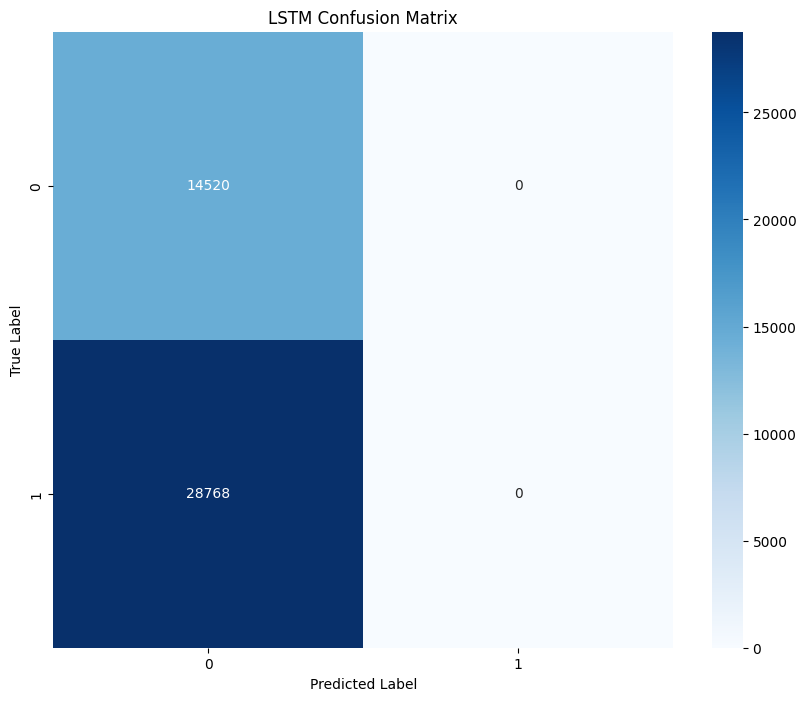

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate LSTM model
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_te, y_te, verbose=1)
print(f"LSTM Test Loss: {lstm_loss:.4f}, Test Accuracy: {lstm_accuracy:.4f}")
y_pred_lstm = np.argmax(lstm_model.predict(X_te), axis=1)
print(classification_report(y_te, y_pred_lstm))
cm_lstm = confusion_matrix(y_te, y_pred_lstm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues')
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


In [ ]:
probs = lstm_model.predict(X_te).ravel()

print("Some raw probs:", probs[:20])
print("Min / max prob on test:", probs.min(), probs.max())


1353/1353 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step
Some raw probs: [0.67186624 0.67186624 0.67186624 0.67186624 0.67186624 0.67186624
 0.67186624 0.67186624 0.67186624 0.67186624 0.67186624 0.67186624
 0.67186624 0.67186624 0.67186624 0.67186624 0.67186624 0.67186624
 0.67186624 0.67186624]
Min / max prob on test: 0.67186624 0.67186624


In [ ]:
print("Train mean:", X_tr.mean(), "Test mean:", X_te.mean())
print("Train std:", X_tr.std(), "Test std:", X_te.std())



Train mean: nan Test mean: 0.016563315089727894
Train std: nan Test std: 0.8836071334011132


In [ ]:
from tensorflow.keras import layers, models, Input

def tcn_block(x, filters, kernel_size=3, dilation_rate=1, dropout=0.2):
    # First dilated conv
    conv1 = layers.Conv1D(filters, kernel_size, padding='causal',
                          dilation_rate=dilation_rate, activation='relu')(x)
    conv1 = layers.Dropout(dropout)(conv1)

    # Second dilated conv
    conv2 = layers.Conv1D(filters, kernel_size, padding='causal',
                          dilation_rate=dilation_rate, activation='relu')(conv1)

    # Residual connection (adjust dims if needed)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding='same')(x)
    out = layers.add([conv2, x])
    out = layers.LayerNormalization()(out)
    return out

def create_tcn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Stack residual blocks with increasing dilation
    x = tcn_block(inputs, filters=64, dilation_rate=1)
    x = tcn_block(x, filters=64, dilation_rate=2)
    x = tcn_block(x, filters=64, dilation_rate=4)

    # Global pooling to collapse time
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model



In [ ]:
tcn_model = create_tcn_model((X_tr_w.shape[1], X_tr_w.shape[2]))

history = tcn_model.fit(X_tr_w, y_tr, 
               validation_data=(X_va_w, y_va), 
               epochs=35,
               batch_size=64,
               class_weight=class_weight_dict,
               verbose=1) #,
               # callbacks=[lr_schedule])

Epoch 1/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.4133 - loss: 0.6943 - val_accuracy: 0.6582 - val_loss: 0.6916
Epoch 2/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.5798 - loss: 0.6929 - val_accuracy: 0.3418 - val_loss: 0.6940
Epoch 3/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.4703 - loss: 0.6923 - val_accuracy: 0.6582 - val_loss: 0.6922
Epoch 4/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5206 - loss: 0.6935 - val_accuracy: 0.6582 - val_loss: 0.6927
Epoch 5/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5259 - loss: 0.6934 - val_accuracy: 0.6582 - val_loss: 0.6920
Epoch 6/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5321 - loss: 0.6930 - val_accuracy: 0.3418 - val_loss: 0.6945
Epoch 7/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.3811 - loss: 0.6941 - val_accuracy: 0.6582 - val_loss: 0.6911
Epoch 8/35
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5597 -

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

probs = tcn_model.predict(X_te_w).ravel()
# y_te  = ...

thresholds = np.linspace(0.05, 0.95, 19)

results = []

print("thr   acc   bal_acc  prec   rec    f1   ")
for thr in thresholds:
    y_pred = (probs >= thr).astype(int)
    
    acc  = accuracy_score(y_te, y_pred)
    bacc = balanced_accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    
    results.append((thr, acc, bacc, prec, rec, f1))
    print(f"{thr:4.2f}  {acc:5.3f}  {bacc:7.3f}  {prec:5.3f}  {rec:5.3f}  {f1:5.3f}")

# pick best threshold by F1 (or change idx=... for other metric)
results = np.array(results, dtype=float)
best_idx = np.argmax(results[:, -1])  # last col = F1
best_thr, best_acc, best_bacc, best_prec, best_rec, best_f1 = results[best_idx]

print("\nBest by F1:")
print(f"  thr={best_thr:4.2f}  acc={best_acc:5.3f}  bal_acc={best_bacc:5.3f}  "
      f"prec={best_prec:5.3f}  rec={best_rec:5.3f}  f1={best_f1:5.3f}")


481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
thr   acc   bal_acc  prec   rec    f1   
0.05  0.660    0.500  0.660  1.000  0.795
0.10  0.660    0.500  0.660  1.000  0.795
0.15  0.660    0.500  0.660  1.000  0.795
0.20  0.660    0.500  0.660  1.000  0.795
0.25  0.660    0.500  0.660  1.000  0.795
0.30  0.660    0.500  0.660  1.000  0.795
0.35  0.660    0.500  0.660  1.000  0.795
0.40  0.660    0.500  0.660  1.000  0.795
0.45  0.660    0.500  0.660  1.000  0.795
0.50  0.660    0.500  0.660  1.000  0.795
0.55  0.340    0.500  0.000  0.000  0.000
0.60  0.340    0.500  0.000  0.000  0.000
0.65  0.340    0.500  0.000  0.000  0.000
0.70  0.340    0.500  0.000  0.000  0.000
0.75  0.340    0.500  0.000  0.000  0.000
0.80  0.340    0.500  0.000  0.000  0.000
0.85  0.340    0.500  0.000  0.000  0.000
0.90  0.340    0.500  0.000  0.000  0.000
0.95  0.340    0.500  0.000  0.000  0.000

Best by F1:
  thr=0.05  acc=0.660  bal_acc=0.500  prec=0.660  rec=1.000  f1=0.795


1353/1353 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14520
           1       0.66      1.00      0.80     28768

    accuracy                           0.66     43288
   macro avg       0.33      0.50      0.40     43288
weighted avg       0.44      0.66      0.53     43288



C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

Text(95.72222222222221, 0.5, 'True Label')

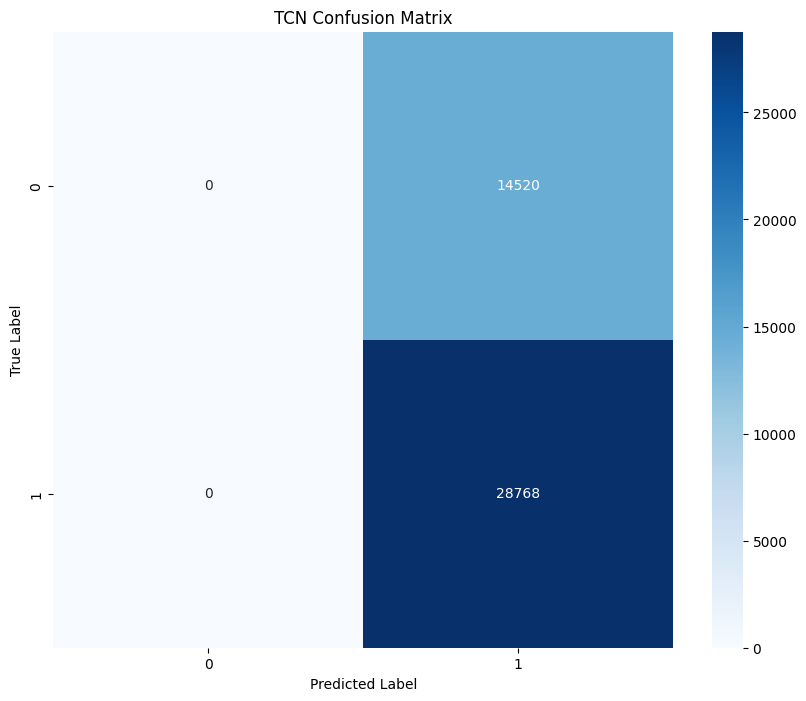

In [ ]:
y_pred_tcn = (tcn_model.predict(X_te_w) > 0.5).astype("int32")
print(classification_report(y_te, y_pred_tcn))
cm_tcn = confusion_matrix(y_te, y_pred_tcn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tcn, annot=True, fmt='d', cmap='Blues')
plt.title('TCN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_spoof_model(
    time_steps: int,             # e.g., 100
    n_features: int,             # e.g., X_tr.shape[-1]
    conv1_filters=64, conv1_kernel=64,
    pool1_size=2,
    rnn_units=64, rnn_type="lstm",   # set "gru" to use GRU
    pool2_size=2,
    conv2_filters=128, conv2_kernel=128,
    dense_units=128, dropout=0.3,
    learning_rate=1e-3
):
    # Clip kernels if they exceed the current temporal length
    k1 = min(conv1_kernel, time_steps)
    k2 = min(conv2_kernel, max(1, time_steps // (pool1_size * pool2_size)))

    inp = layers.Input(shape=(time_steps, n_features), name="Input")

    x = layers.Conv1D(conv1_filters, k1, padding="same", activation="relu",
                      name="Conv1D_64x64")(inp)
    x = layers.MaxPooling1D(pool_size=pool1_size, name="MaxPool1D_1")(x)
    x = layers.BatchNormalization(name="BatchNorm_1")(x)

    rnn_layer = layers.GRU if rnn_type.lower() == "gru" else layers.LSTM
    x = layers.Bidirectional(rnn_layer(rnn_units, return_sequences=True),
                             name="Bidirectional")(x)
    x = layers.BatchNormalization(name="BatchNorm_2")(x)

    x = layers.MaxPooling1D(pool_size=pool2_size, name="MaxPool1D_2")(x)
    x = layers.Conv1D(conv2_filters, k2, padding="same", activation="relu",
                      name="Conv1D_128x128")(x)

    x = layers.Flatten(name="Flatten")(x)
    x = layers.Dense(dense_units, activation="relu", name="FullyConnected")(x)
    x = layers.Dropout(dropout, name="Dropout")(x)
    x = layers.BatchNormalization(name="BatchNorm_3")(x)

    out = layers.Dense(1, activation="sigmoid", name="Sigmoid")(x)

    model = models.Model(inputs=inp, outputs=out, name="CNN_BiRNN_1D")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="AUC"),
                 tf.keras.metrics.Precision(name="Precision"),
                 tf.keras.metrics.Recall(name="Recall")]
    )
    return model


In [ ]:
# X_tr shape: (N, time_steps, n_features); y_tr: (N,)
time_steps  = X_tr_w.shape[1]
n_features  = X_tr_w.shape[2]

spoof_model = build_spoof_model(time_steps, n_features,
                          conv1_filters=64, conv1_kernel=64,
                          conv2_filters=128, conv2_kernel=128,
                          rnn_units=64, rnn_type="lstm",
                          dense_units=128, dropout=0.3,
                          learning_rate=1e-3)

spoof_model.summary()
history = spoof_model.fit(X_tr_w, y_tr, validation_data=(X_va_w, y_va),
                    epochs=30, batch_size=128, shuffle=True)

Model: "CNN_BiRNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 200, 26)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_64x64 (Conv1D)           │ (None, 200, 64)        │       106,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1D_1 (MaxPooling1D)      │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bidirectional (Bidirectional)   │ (None, 100, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1D_2 (MaxPooling1D)      │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_128x128 (Conv1D)         │ (None, 50, 128)        │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FullyConnected (Dense)          │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_3                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sigmoid (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,812,673 (6.91 MB)

 Trainable params: 1,812,033 (6.91 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - AUC: 0.4949 - Precision: 0.6616 - Recall: 0.9802 - loss: 0.6478 - val_AUC: 0.5000 - val_Precision: 0.6646 - val_Recall: 1.0000 - val_loss: 0.6380
Epoch 2/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - AUC: 0.4960 - Precision: 0.6676 - Recall: 1.0000 - loss: 0.6360 - val_AUC: 0.5000 - val_Precision: 0.6646 - val_Recall: 1.0000 - val_loss: 0.6381
Epoch 3/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - AUC: 0.4989 - Precision: 0.6628 - Recall: 1.0000 - loss: 0.6395 - val_AUC: 0.5000 - val_Precision: 0.6646 - val_Recall: 1.0000 - val_loss: 0.6380
Epoch 4/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - AUC: 0.4945 - Precision: 0.6617 - Recall: 1.0000 - loss: 0.6401 - val_AUC: 0.5000 - val_Precision: 0.6646 - val_Recall: 1.0000 - val_loss: 0.6380
Epoch 5/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - AUC: 0.4945 - Precision: 0.6641 - Recall: 1.0000 - loss: 0.6384 - val_AUC: 0.5000 - val_Precision: 0.6646 - val_Recall: 1.0000 - va

1348/1348 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step
              precision    recall  f1-score   support

           0       0.14      1.00      0.24      5876
           1       0.00      0.00      0.00      6276
           2       0.00      0.00      0.00      6124
           3       0.00      0.00      0.00      5932
           4       0.00      0.00      0.00      6212
           5       0.00      0.00      0.00      6356
           6       0.00      0.00      0.00      6356

    accuracy                           0.14     43132
   macro avg       0.02      0.14      0.03     43132
weighted avg       0.02      0.14      0.03     43132



C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

Text(95.72222222222221, 0.5, 'True Label')

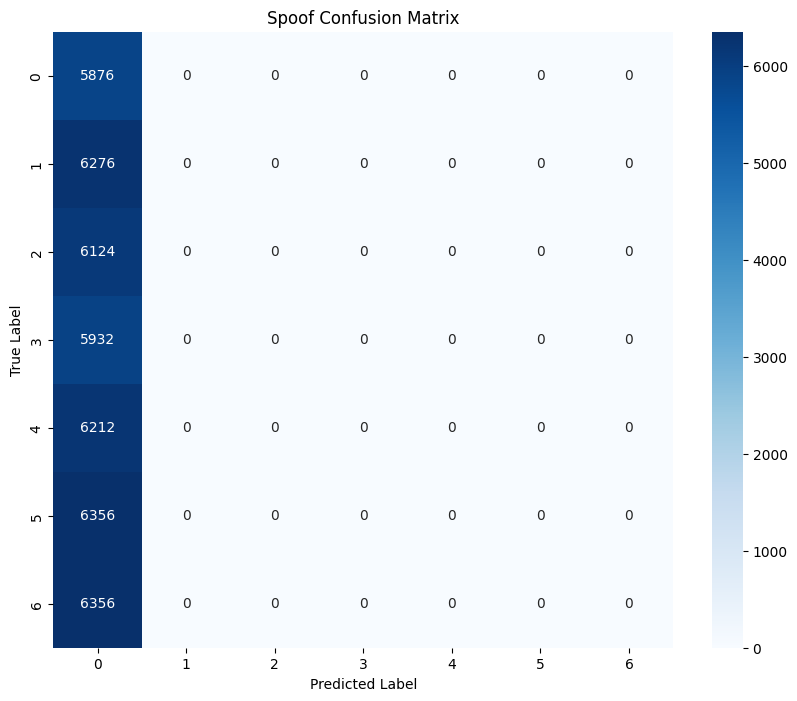

In [ ]:
y_pred_spoof = np.argmax(spoof_model.predict(X_te_w), axis=1)
print(classification_report(y_te, y_pred_spoof))
cm_spoof = confusion_matrix(y_te, y_pred_spoof)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_spoof, annot=True, fmt='d', cmap='Blues')
plt.title('Spoof Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [25]:
def add_iq_drift_features(df: pd.DataFrame, window: int = 128, eps: float = 1e-9) -> pd.DataFrame:
    required = {'prompt_i','prompt_q','sample_id','prn','seq'}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns for drift features: {missing}")

    out = df.sort_values(['sample_id','prn','seq']).copy()

    out['mag'] = np.hypot(out['prompt_i'], out['prompt_q'])

    def _unwrap_phase(g):
        ph = np.arctan2(g['prompt_q'].to_numpy(), g['prompt_i'].to_numpy())
        return pd.Series(np.unwrap(ph), index=g.index)

    out['phase'] = out.groupby(['sample_id','prn'], sort=False).apply(_unwrap_phase)\
                      .reset_index(level=[0,1], drop=True)

    out['dphase'] = out.groupby(['sample_id','prn'], sort=False)['phase']\
                       .diff().fillna(0.0)

    dI = out.groupby(['sample_id','prn'], sort=False)['prompt_i'].diff()
    dQ = out.groupby(['sample_id','prn'], sort=False)['prompt_q'].diff()
    step_len = np.hypot(dI, dQ).fillna(0.0)

    out['pathlen_w'] = step_len.groupby([out['sample_id'], out['prn']], sort=False)\
                               .rolling(window, min_periods=2).sum()\
                               .reset_index(level=[0,1], drop=True)

    I_lag = out.groupby(['sample_id','prn'], sort=False)['prompt_i'].shift(window-1)
    Q_lag = out.groupby(['sample_id','prn'], sort=False)['prompt_q'].shift(window-1)
    out['net_disp_w'] = np.hypot(out['prompt_i'] - I_lag,
                                 out['prompt_q'] - Q_lag)

    out['tortuosity_w'] = out['pathlen_w'] / (out['net_disp_w'] + eps)

    out['dphase_mean_w'] = out.groupby(['sample_id','prn'], sort=False)['dphase']\
                              .rolling(window, min_periods=5).mean()\
                              .reset_index(level=[0,1], drop=True)

    out['dphase_std_w'] = out.groupby(['sample_id','prn'], sort=False)['dphase']\
                             .rolling(window, min_periods=5).std()\
                             .reset_index(level=[0,1], drop=True)

    def _rolling_slope(y: np.ndarray) -> float:
        n = len(y)
        if n < 2:
            return np.nan
        x = np.arange(n, dtype=float)
        x = x - x.mean()
        y = y.astype(float)
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 2:
            return np.nan
        x = x[mask]; y = y[mask]
        denom = np.dot(x, x)
        if denom == 0:
            return 0.0
        return float(np.dot(x, y - y.mean()) / denom)

    out['phase_slope_w'] = out.groupby(['sample_id','prn'], sort=False)['phase']\
                              .rolling(window, min_periods=5)\
                              .apply(_rolling_slope, raw=True)\
                              .reset_index(level=[0,1], drop=True)

    out['mag_slope_w'] = out.groupby(['sample_id','prn'], sort=False)['mag']\
                            .rolling(window, min_periods=5)\
                            .apply(_rolling_slope, raw=True)\
                            .reset_index(level=[0,1], drop=True)

    def _ellipse_ratio_group(g):
        I = g['prompt_i'].to_numpy()
        Q = g['prompt_q'].to_numpy()
        n = len(g)
        out_arr = np.full(n, np.nan, dtype=float)
        if n < 5:
            return pd.Series(out_arr, index=g.index)
        for t in range(n):
            s = max(0, t - (window - 1))
            m = t - s + 1
            if m < 5:
                continue
            Ii = I[s:t+1]
            Qi = Q[s:t+1]
            C = np.cov(np.vstack([Ii, Qi]))
            if not np.isfinite(C).all():
                continue
            vals = np.linalg.eigvalsh(C)
            if vals[0] <= 0 or vals[1] <= 0:
                continue
            out_arr[t] = float(vals[1] / vals[0])
        return pd.Series(out_arr, index=g.index)

    out['ellipse_ratio_w'] = out.groupby(['sample_id','prn'], sort=False)\
                                .apply(_ellipse_ratio_group)\
                                .reset_index(level=[0,1], drop=True)

    return out

def add_attr_columns_per_sample(samples, attr_map):
    """
    Add time_push, pos_push, overpowered columns to each per-scenario DF.
    attr_map: {sample_id: {time_push:0/1, pos_push:0/1, overpowered:0/1}}
    """
    out = []
    for sid, df in enumerate(samples):
        df = df.copy()
        attrs = attr_map.get(sid, {})
        for k in ['time_push', 'pos_push', 'overpowered']:
            df[k] = attrs.get(k, 0)
        out.append(df)
    return out

def make_sample_weight(y, class_weight_dict):
    """
    y: 1D array of 0/1 labels
    class_weight_dict: {0: w0, 1: w1}
    returns: 1D array of weights (same length as y)
    """
    y_int = y.astype(int)
    w0 = class_weight_dict[0]
    w1 = class_weight_dict[1]
    return np.where(y_int == 1, w1, w0).astype('float32')


In [26]:
def make_multilabel_sequences(df,
                              time_steps=200,
                              step=1,
                              feat_cols=None,
                              label_cols=('time_push','pos_push','overpowered')):
    """
    Build sequences and multi-label targets for each window.
    Returns:
        X : (num_windows, time_steps, num_features)
        ys: dict {label_name: np.ndarray of shape (num_windows,)}
    """
    if feat_cols is None:
        raise ValueError("feat_cols must be provided.")

    Xs = []
    ys_dict = {name: [] for name in label_cols}

    df_sorted = df.sort_values(['sample_id', 'prn', 'seq'])

    for (_, _), g in df_sorted.groupby(['sample_id', 'prn'], sort=False):
        Xg = g[feat_cols].to_numpy()
        ng = len(g)
        if ng < time_steps:
            continue

        label_arrays = {name: g[name].to_numpy() for name in label_cols}

        for i in range(0, ng - time_steps + 1, step):
            Xs.append(Xg[i:i+time_steps])
            idx_label = i + time_steps - 1
            for name in label_cols:
                ys_dict[name].append(label_arrays[name][idx_label])

    X = np.asarray(Xs)
    ys = {name: np.asarray(vals).astype('float32') for name, vals in ys_dict.items()}
    return X, ys


In [27]:
# dicts_with_labels = [(dataset0, label0), (dataset1, label1), ...]
# index 0 = clean → drop it
keep_idx = list(range(1, len(dicts_with_labels)))   # [1,2,3,4,5,6]
dicts_spoof = [dicts_with_labels[i] for i in keep_idx]

def build_samples(dicts_with_labels, skip_head: int = 100):
    samples = []
    for sid, (dataset, label) in enumerate(dicts_with_labels):
        dfs = []
        for prn in dataset['prn']:
            g = dataset[prn].copy().reset_index(drop=True)
            g['sample_id'] = sid
            g['spoofed']   = label
            g['prn']       = prn

            if skip_head > 0 and len(g) > 0:
                g = g.iloc[skip_head:, :]

            if len(g) > 0:
                g['seq'] = np.arange(1, len(g)+1, dtype=np.int64)
            dfs.append(g)
        samples.append(pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame())
    return samples

SKIP_HEAD_PRN = 100
samples = build_samples(dicts_spoof, skip_head=SKIP_HEAD_PRN)

# Scenario mapping after dropping clean:
#   sample_id 0 -> ds1
#   sample_id 1 -> ds2
#   sample_id 2 -> ds3
#   sample_id 3 -> ds4
#   sample_id 4 -> ds7
#   sample_id 5 -> ds8
attr_map = {
    0: dict(time_push=0, pos_push=0, overpowered=0),  # ds1: static switch
    1: dict(time_push=1, pos_push=0, overpowered=1),  # ds2: overpowered time push
    2: dict(time_push=1, pos_push=0, overpowered=0),  # ds3: matched-power time push
    3: dict(time_push=0, pos_push=1, overpowered=0),  # ds4: matched-power pos push
    4: dict(time_push=1, pos_push=0, overpowered=0),  # ds7: matched-power time push (phase aligned)
    5: dict(time_push=1, pos_push=0, overpowered=0),  # ds8: matched-power time push (SCER)
}

# Add drift features
DRIFT_WINDOW = 128
samples = [add_iq_drift_features(df, window=DRIFT_WINDOW) for df in samples]

# Add attribute columns
samples = add_attr_columns_per_sample(samples, attr_map)

# Combine all spoof scenarios
df_all = pd.concat(samples, ignore_index=True)


C:\Users\nicho\AppData\Local\Temp\ipykernel_7968\2114363341.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['phase'] = out.groupby(['sample_id','prn'], sort=False).apply(_unwrap_phase)\
C:\Users\nicho\AppData\Local\Temp\ipykernel_7968\2114363341.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_ellipse_ratio_group)\
C:\Users\nicho\AppData\Local\Temp\ipykernel_7968\2114363341.py:15: Depre

In [28]:
feature_cols = [
    'prompt_i','prompt_q','mag','phase','dphase',
    'pathlen_w','net_disp_w','tortuosity_w',
    'dphase_mean_w','dphase_std_w',
    'phase_slope_w','mag_slope_w','ellipse_ratio_w'
]

scaler = StandardScaler().fit(df_all[feature_cols].values)

def scale_df(df):
    Xs = scaler.transform(df[feature_cols].values)
    Xs = pd.DataFrame(Xs, index=df.index, columns=feature_cols)
    return Xs.join(df[['spoofed','prn','sample_id','seq',
                       'time_push','pos_push','overpowered']])

df_all_s = scale_df(df_all)

TIME_STEPS = 200
X_all, ys_all = make_multilabel_sequences(
    df_all_s,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_cols=('time_push','pos_push','overpowered')
)


In [29]:
n = len(X_all)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

train_idx = idx[:train_end]
val_idx   = idx[train_end:val_end]
test_idx  = idx[val_end:]

X_tr, X_va, X_te = X_all[train_idx], X_all[val_idx], X_all[test_idx]

y_tr = {name: arr[train_idx] for name, arr in ys_all.items()}
y_va = {name: arr[val_idx]   for name, arr in ys_all.items()}
y_te = {name: arr[test_idx]  for name, arr in ys_all.items()}


In [32]:
def create_multihead_lstm(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.LSTM(64, return_sequences=True, recurrent_dropout=0.05)(inputs)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(32, return_sequences=False, recurrent_dropout=0.05)(x)
    x = layers.Dropout(0.25)(x)
    base = layers.Dense(32, activation='relu')(x)
    base = layers.Dropout(0.3)(base)

    time_out = layers.Dense(1, activation='sigmoid', name='time_push')(base)
    pos_out  = layers.Dense(1, activation='sigmoid', name='pos_push')(base)
    over_out = layers.Dense(1, activation='sigmoid', name='overpowered')(base)

    model = models.Model(inputs=inputs, outputs=[time_out, pos_out, over_out])

    model.compile(
        optimizer=Adam(1e-3),
        loss={
            'time_push': 'binary_crossentropy',
            'pos_push': 'binary_crossentropy',
            'overpowered': 'binary_crossentropy',
        },
        loss_weights={
            'time_push': 1.0,
            'pos_push': 1.0,
            'overpowered': 1.5,  # overweight rare "overpowered" label
        },
        metrics={
            'time_push': 'accuracy',
            'pos_push': 'accuracy',
            'overpowered': 'accuracy',
        }
    )
    return model

multi_model = create_multihead_lstm(X_tr.shape[1:])
multi_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 200, 64)   │     19,968 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 200, 64)   │          0 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 32)        │     12,416 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 32)        │          0 │ lstm_7[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      1,056 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ dense_5[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_push (Dense)   │ (None, 1)         │         33 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_push (Dense)    │ (None, 1)         │         33 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ overpowered (Dense) │ (None, 1)         │         33 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,539 (131.01 KB)

 Trainable params: 33,539 (131.01 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
def make_cw(y):
    classes = np.array([0,1])
    cw = compute_class_weight('balanced', classes=classes, y=y.astype(int))
    return {0: cw[0], 1: cw[1]}

cw_time = make_cw(y_tr['time_push'])
cw_pos  = make_cw(y_tr['pos_push'])
cw_over = make_cw(y_tr['overpowered'])

sw_time = make_sample_weight(y_tr['time_push'],   cw_time)
sw_pos  = make_sample_weight(y_tr['pos_push'],    cw_pos)
sw_over = make_sample_weight(y_tr['overpowered'], cw_over)

sample_weight = {
    'time_push': sw_time,
    'pos_push': sw_pos,
    'overpowered': sw_over,
}



In [ ]:
history = multi_model.fit(
    X_tr,
    {
        'time_push': y_tr['time_push'],
        'pos_push': y_tr['pos_push'],
        'overpowered': y_tr['overpowered'],
    },
    validation_data=(
        X_va,
        {
            'time_push': y_va['time_push'],
            'pos_push': y_va['pos_push'],
            'overpowered': y_va['overpowered'],
        }
    ),
    epochs=35,
    batch_size=64,
    sample_weight=sample_weight,   # or remove if you want unweighted
    verbose=1
)


Epoch 1/35
1863/1863 ━━━━━━━━━━━━━━━━━━━━ 101s 53ms/step - loss: 2.4240 - overpowered_accuracy: 0.6835 - overpowered_loss: 0.6941 - pos_push_accuracy: 0.5300 - pos_push_loss: 0.6931 - time_push_accuracy: 0.4416 - time_push_loss: 1.0367 - val_loss: 2.4202 - val_overpowered_accuracy: 0.1566 - val_overpowered_loss: 0.6918 - val_pos_push_accuracy: 0.1702 - val_pos_push_loss: 0.6937 - val_time_push_accuracy: 0.3406 - val_time_push_loss: 1.0348
Epoch 2/35
1863/1863 ━━━━━━━━━━━━━━━━━━━━ 98s 53ms/step - loss: 2.4262 - overpowered_accuracy: 0.4137 - overpowered_loss: 0.6933 - pos_push_accuracy: 0.5433 - pos_push_loss: 0.6928 - time_push_accuracy: 0.4347 - time_push_loss: 1.0401 - val_loss: 2.4243 - val_overpowered_accuracy: 0.8434 - val_overpowered_loss: 0.6940 - val_pos_push_accuracy: 0.8298 - val_pos_push_loss: 0.6912 - val_time_push_accuracy: 0.3406 - val_time_push_loss: 1.0391
Epoch 3/35
1863/1863 ━━━━━━━━━━━━━━━━━━━━ 104s 56ms/step - loss: 2.4308 - overpowered_accuracy: 0.5650 - overpowere

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

# 1) Get probabilities from the multi-head model
pred_time, pred_pos, pred_over = multi_model.predict(X_te, verbose=1)
probs = {
    'time_push': pred_time.ravel(),
    'pos_push':  pred_pos.ravel(),
    'overpowered': pred_over.ravel(),
}

# 2) Helper to evaluate one head
def eval_head(name, y_true, y_prob, thr=0.5):
    print(f"\n=== {name} ===")

    y_true = y_true.astype(int)
    y_pred = (y_prob >= thr).astype(int)

    # class balance
    vals, counts = np.unique(y_true, return_counts=True)
    print("Class counts:")
    for v, c in zip(vals, counts):
        print(f"  {v}: {c} ({c/len(y_true):.3f})")

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion matrix (rows=true, cols=pred):")
    print(cm)

    # basic metrics
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float('nan')

    print(f"\nAccuracy:          {acc:.3f}")
    print(f"Balanced accuracy: {bacc:.3f}")
    print(f"ROC AUC:           {auc:.3f}")

    # detailed per-class metrics
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3))

# 3) Run for each head (using default thr=0.5 for now)
eval_head('time_push',   y_te['time_push'],   probs['time_push'],   thr=0.5)
eval_head('pos_push',    y_te['pos_push'],    probs['pos_push'],    thr=0.5)
eval_head('overpowered', y_te['overpowered'], probs['overpowered'], thr=0.5)


466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step

=== time_push ===
Class counts:
  0: 5086 (0.341)
  1: 9817 (0.659)

Confusion matrix (rows=true, cols=pred):
[[   0 5086]
 [   0 9817]]

Accuracy:          0.659
Balanced accuracy: 0.500
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      5086
           1      0.659     1.000     0.794      9817

    accuracy                          0.659     14903
   macro avg      0.329     0.500     0.397     14903
weighted avg      0.434     0.659     0.523     14903


=== pos_push ===
Class counts:
  0: 12410 (0.833)
  1: 2493 (0.167)

Confusion matrix (rows=true, cols=pred):
[[12410     0]
 [ 2493     0]]

Accuracy:          0.833
Balanced accuracy: 0.500
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

           0      0.833     1.000     0.909     12410
           1      0.000     0.000     0.00

C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

In [ ]:
def make_sequences(df,
                   time_steps=200,
                   step=1,
                   feat_cols=None,
                   label_col='sample_id'):
    if feat_cols is None:
        raise ValueError("feat_cols must be provided.")

    Xs, ys = [], []

    df_sorted = df.sort_values(['sample_id', 'prn', 'seq'])

    for (_, _), g in df_sorted.groupby(['sample_id', 'prn'], sort=False):
        Xg = g[feat_cols].to_numpy()
        yg = g[label_col].to_numpy()
        n = len(g)

        if n < time_steps:
            continue

        for i in range(0, n - time_steps + 1, step):
            Xs.append(Xg[i:i+time_steps])
            ys.append(yg[i + time_steps - 1])

    return np.asarray(Xs), np.asarray(ys)


In [ ]:
TIME_STEPS = 200
X_all, y_all_cls = make_sequences(
    df_all_s,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_col='sample_id'
)

print("X_all:", X_all.shape, " y_all_cls:", y_all_cls.shape)
print("Unique classes:", np.unique(y_all_cls))


X_all: (149024, 200, 13)  y_all_cls: (149024,)
Unique classes: [0 1 2 3 4 5]


In [ ]:
n = len(X_all)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

train_idx = idx[:train_end]
val_idx   = idx[train_end:val_end]
test_idx  = idx[val_end:]

X_tr_cls, X_va_cls, X_te_cls = X_all[train_idx], X_all[val_idx], X_all[test_idx]
y_tr_cls = y_all_cls[train_idx]
y_va_cls = y_all_cls[val_idx]
y_te_cls = y_all_cls[test_idx]

print("train cls dist:", np.unique(y_tr_cls, return_counts=True))
print("val   cls dist:", np.unique(y_va_cls, return_counts=True))
print("test  cls dist:", np.unique(y_te_cls, return_counts=True))


train cls dist: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([19972, 19741, 19041, 19818, 20378, 20269], dtype=int64))
val   cls dist: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([2539, 2333, 2383, 2537, 2545, 2565], dtype=int64))
test  cls dist: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([2593, 2422, 2304, 2493, 2501, 2590], dtype=int64))


In [ ]:
from tensorflow.keras import layers, models, optimizers

def create_sixway_model(input_shape, n_classes=6):
    inputs = layers.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=True, recurrent_dropout=0.05)(inputs)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(32, return_sequences=False, recurrent_dropout=0.05)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Take a tiny slice
X_small = X_tr_cls[:512]
y_small = y_tr_cls[:512]

small_model = create_sixway_model(X_small.shape[1:])

hist = small_model.fit(
    X_small, y_small,
    epochs=80,
    batch_size=32,
    verbose=0
)

print("Tiny-set final acc:", hist.history['accuracy'][-1])
print("Tiny-set final loss:", hist.history['loss'][-1])


Tiny-set final acc: 0.1875
Tiny-set final loss: 1.7846243381500244


In [ ]:
print("Unique classes in y_all_cls:", np.unique(y_all_cls))


Unique classes in y_all_cls: [0 1 2 3 4 5]


In [ ]:
X_small = X_tr_cls[:512]
y_small = y_tr_cls[:512]

print("Tiny labels (first 50):", y_small[:50])
print("Unique tiny labels:", np.unique(y_small, return_counts=True))


Tiny labels (first 50): [5 5 0 4 1 2 2 4 0 0 2 3 5 4 2 1 1 2 0 2 2 2 1 3 2 1 5 4 0 1 2 4 4 3 0 2 2
 2 3 2 0 1 3 3 2 2 0 3 2 0]
Unique tiny labels: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([66, 86, 95, 81, 96, 88], dtype=int64))


In [ ]:
# Toy label: depends on the *actual X*, not df_all_s plumbing
X_flat_mean = X_all.mean(axis=1)            # shape (num_windows, num_features)
toy_label = (X_flat_mean[:, 0] > 0).astype(int)  # 0/1 based on first feature mean

X_small_toy = X_all[:512]
y_small_toy = toy_label[:512]

print("Toy tiny label distribution:", np.unique(y_small_toy, return_counts=True))


Toy tiny label distribution: (array([0, 1]), array([412, 100], dtype=int64))


In [ ]:
toy_model = create_sixway_model(X_small_toy.shape[1:], n_classes=2)  # 2 classes

toy_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hist_toy = toy_model.fit(
    X_small_toy, y_small_toy,
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Toy tiny-set final acc:", hist_toy.history['accuracy'][-1])
print("Toy tiny-set final loss:", hist_toy.history['loss'][-1])


Toy tiny-set final acc: 0.8046875
Toy tiny-set final loss: 0.5050250887870789


In [ ]:
# scenario ID = sample_id, 0..5 for [ds1, ds2, ds3, ds4, ds7, ds8]
TIME_STEPS = 200

X_all, y_all_cls = make_sequences(
    df_all_s,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_col='sample_id'
)

print("X_all shape:", X_all.shape)
print("Unique scenario IDs:", np.unique(y_all_cls))


X_all shape: (149024, 200, 13)
Unique scenario IDs: [0 1 2 3 4 5]


C:\Users\nicho\AppData\Local\Temp\ipykernel_11924\9064502.py:7: RuntimeWarning: Mean of empty slice
  X_summary = np.nanmean(X_all, axis=1)   # (N_windows, n_features)
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


X_feat shape for viz: (149024, 26)
Kept windows: 149004  /  149024


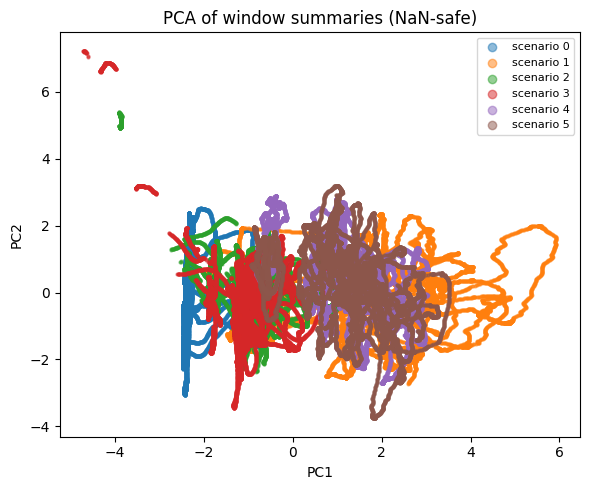

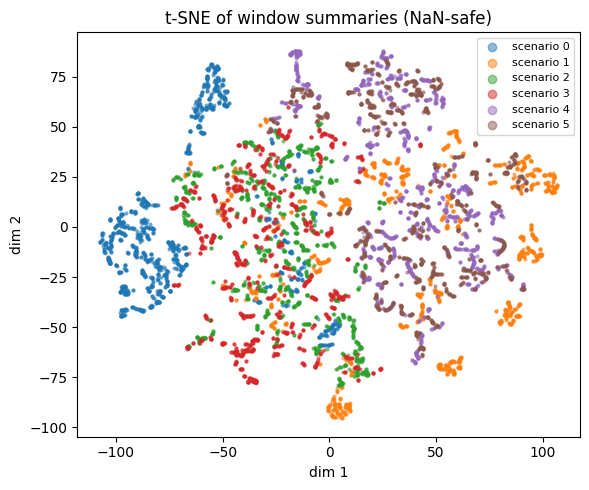

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ---- Summarize each window with NaN-safe stats
X_summary = np.nanmean(X_all, axis=1)   # (N_windows, n_features)
X_std     = np.nanstd(X_all, axis=1)    # (N_windows, n_features)
X_feat    = np.concatenate([X_summary, X_std], axis=1)

print("X_feat shape for viz:", X_feat.shape)

# ---- Drop any rows that are still non-finite
finite_mask = np.isfinite(X_feat).all(axis=1)
X_feat_clean = X_feat[finite_mask]
y_cls_clean  = y_all_cls[finite_mask]

print("Kept windows:", X_feat_clean.shape[0], " / ", X_feat.shape[0])

# ---- PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_feat_clean)

plt.figure(figsize=(6, 5))
for sid in np.unique(y_cls_clean):
    mask = (y_cls_clean == sid)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=4, alpha=0.5, label=f"scenario {sid}")
plt.title("PCA of window summaries (NaN-safe)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

# ---- t-SNE (on cleaned subset)
max_points = 8000
if X_feat_clean.shape[0] > max_points:
    idx = np.random.choice(X_feat_clean.shape[0], max_points, replace=False)
    X_tsne_in = X_feat_clean[idx]
    y_tsne    = y_cls_clean[idx]
else:
    X_tsne_in = X_feat_clean
    y_tsne    = y_cls_clean

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_tsne_in)

plt.figure(figsize=(6, 5))
for sid in np.unique(y_tsne):
    mask = (y_tsne == sid)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=4, alpha=0.5, label=f"scenario {sid}")
plt.title("t-SNE of window summaries (NaN-safe)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()


Shapes + class balance:
 time_push: (149024, 200, 13) (array([0, 1], dtype=int64), array([49952, 99072], dtype=int64))
 pos_push:  (149024, 200, 13) (array([0, 1], dtype=int64), array([124176,  24848], dtype=int64))
 overpower: (149024, 200, 13) (array([0, 1], dtype=int64), array([124528,  24496], dtype=int64))


C:\Users\nicho\AppData\Local\Temp\ipykernel_39148\2776938860.py:56: RuntimeWarning: Mean of empty slice
  X_mean = np.nanmean(X, axis=1)  # (N, F)
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



time_push: kept 149004 windows after NaN filtering
 Class counts: (array([0, 1], dtype=int64), array([49932, 99072], dtype=int64))


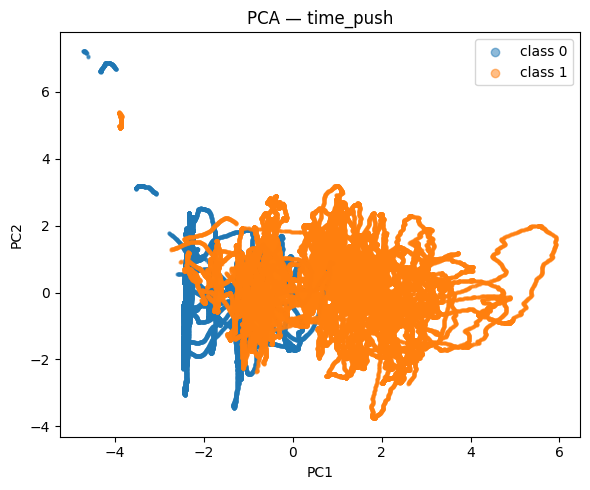

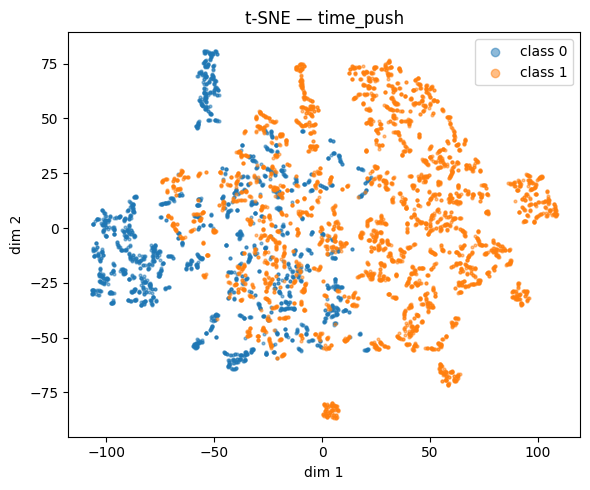

C:\Users\nicho\AppData\Local\Temp\ipykernel_39148\2776938860.py:56: RuntimeWarning: Mean of empty slice
  X_mean = np.nanmean(X, axis=1)  # (N, F)
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



pos_push: kept 149004 windows after NaN filtering
 Class counts: (array([0, 1], dtype=int64), array([124176,  24828], dtype=int64))


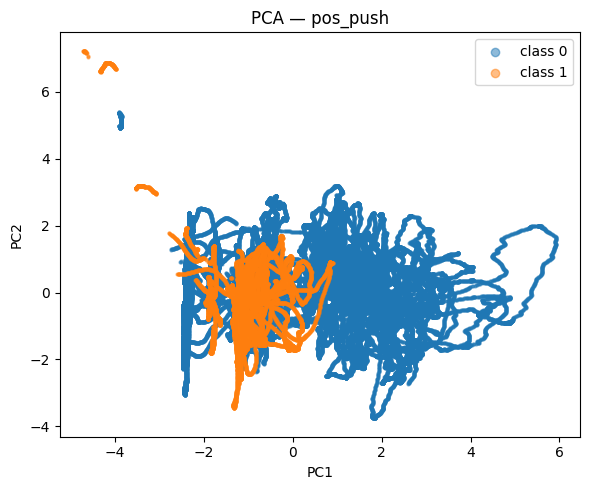

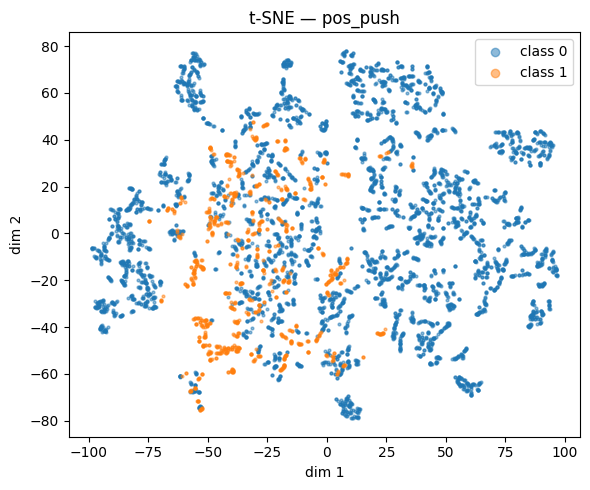

C:\Users\nicho\AppData\Local\Temp\ipykernel_39148\2776938860.py:56: RuntimeWarning: Mean of empty slice
  X_mean = np.nanmean(X, axis=1)  # (N, F)
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



overpowered: kept 149004 windows after NaN filtering
 Class counts: (array([0, 1], dtype=int64), array([124508,  24496], dtype=int64))


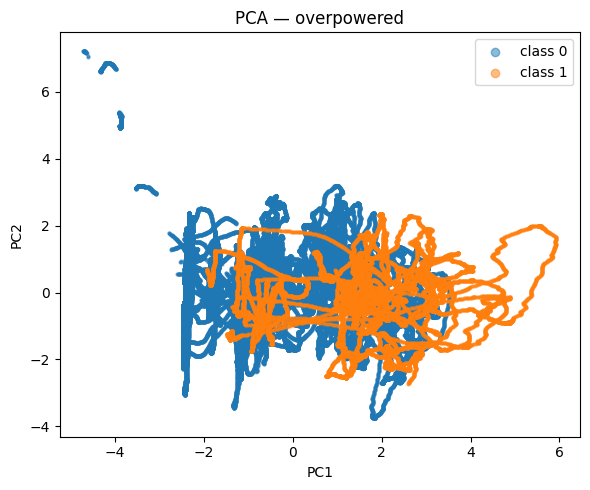

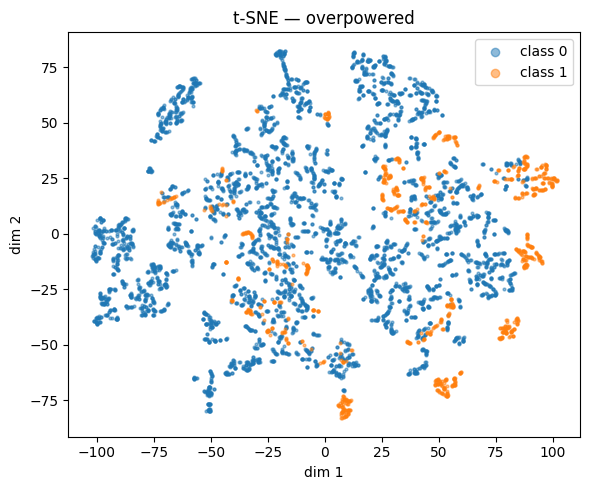

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ---------- 0) Sanity: make_sequences must exist ----------
# def make_sequences(df, time_steps=200, step=1, feat_cols=None, label_col='time_push'):
#     ...

TIME_STEPS = 200

# ---------- 1) Build sequences for each binary head ----------

# time_push sequences
X_tp, y_tp = make_sequences(
    df_all_s,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_col='time_push'
)

# pos_push sequences
X_pp, y_pp = make_sequences(
    df_all_s,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_col='pos_push'
)

# overpowered sequences
X_op, y_op = make_sequences(
    df_all_s,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_col='overpowered'
)

print("Shapes + class balance:")
print(" time_push:", X_tp.shape, np.unique(y_tp, return_counts=True))
print(" pos_push: ", X_pp.shape, np.unique(y_pp, return_counts=True))
print(" overpower:", X_op.shape, np.unique(y_op, return_counts=True))


# ---------- 2) Helper: convert windows to NaN-safe summary features ----------

def window_to_feat(X):
    """
    X: (num_windows, time_steps, num_features)
    Returns:
        X_feat_clean: (N_clean, 2*num_features) [mean + std over time]
        mask: boolean mask of which windows were kept
    """
    X_mean = np.nanmean(X, axis=1)  # (N, F)
    X_std  = np.nanstd(X, axis=1)   # (N, F)
    X_feat = np.concatenate([X_mean, X_std], axis=1)  # (N, 2F)

    # drop any windows that still contain NaNs or inf
    mask = np.isfinite(X_feat).all(axis=1)
    return X_feat[mask], mask


# ---------- 3) Helper: PCA + t-SNE for a binary label ----------

def plot_binary_feature_space(X, y, title):
    """
    X: (num_windows, time_steps, num_features)
    y: (num_windows,) binary labels {0,1}
    title: name of the head (e.g. 'time_push')
    """
    X_feat, mask = window_to_feat(X)
    y = y[mask]

    print(f"\n{title}: kept {X_feat.shape[0]} windows after NaN filtering")
    print(" Class counts:", np.unique(y, return_counts=True))

    # ---- PCA ----
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_feat)

    plt.figure(figsize=(6,5))
    for val, name, color in [(0,"class 0","tab:blue"), (1,"class 1","tab:orange")]:
        m = (y == val)
        plt.scatter(X_pca[m,0], X_pca[m,1],
                    s=4, alpha=0.5, label=name, color=color)
    plt.title(f"PCA — {title}")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(markerscale=3)
    plt.tight_layout()
    plt.show()

    # ---- t-SNE ----
    N = X_feat.shape[0]
    max_pts = 6000
    if N > max_pts:
        idx = np.random.choice(N, max_pts, replace=False)
        X_tsne_in = X_feat[idx]
        y_tsne    = y[idx]
    else:
        X_tsne_in = X_feat
        y_tsne    = y

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        init='pca',
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_tsne_in)

    plt.figure(figsize=(6,5))
    for val, name, color in [(0,"class 0","tab:blue"), (1,"class 1","tab:orange")]:
        m = (y_tsne == val)
        plt.scatter(X_tsne[m,0], X_tsne[m,1],
                    s=4, alpha=0.5, label=name, color=color)
    plt.title(f"t-SNE — {title}")
    plt.xlabel("dim 1"); plt.ylabel("dim 2")
    plt.legend(markerscale=3)
    plt.tight_layout()
    plt.show()


# ---------- 4) Run for all three multi-head labels ----------

plot_binary_feature_space(X_tp, y_tp, "time_push")
plot_binary_feature_space(X_pp, y_pp, "pos_push")
plot_binary_feature_space(X_op, y_op, "overpowered")


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras import layers, models, optimizers

# ---------------------------------------------
# 0) Inspect PRNs and lengths per scenario
# ---------------------------------------------
print("PRNs per sample_id:")
prns_per_sid = df_all_s.groupby('sample_id')['prn'].unique()
for sid, prns in prns_per_sid.items():
    print(f"  sample_id {sid}: {sorted(prns)}")

# Find PRNs common to all scenarios
common_prns = None
for prns in prns_per_sid:
    s = set(prns)
    if common_prns is None:
        common_prns = s
    else:
        common_prns &= s

common_prns = sorted(common_prns) if common_prns else []
print("\nCommon PRNs across all sample_ids:", common_prns)

if not common_prns:
    raise ValueError("No PRNs are common to all scenarios; need to relax strategy (e.g., per-subset).")

# Check min length per (sample_id, PRN)
min_len_global = None
print("\nMin length per (sample_id, prn):")
for (sid, prn), g in df_all_s.groupby(['sample_id', 'prn']):
    L = len(g)
    print(f"  (sid={sid}, prn={prn}): {L}")
    if min_len_global is None or L < min_len_global:
        min_len_global = L

print("\nGlobal minimum track length across all (sid,prn):", min_len_global)

# We'll pick a slightly smaller time_steps for multi-PRN so *everyone* can contribute
TIME_STEPS_MULTI = min(200, max(50, min_len_global // 2))  # heuristic
print("Using TIME_STEPS_MULTI =", TIME_STEPS_MULTI)

# ---------------------------------------------
# 1) Multi-PRN sequence builder (robust)
# ---------------------------------------------
def make_multi_prn_sequences(
    df,
    feature_cols,
    prn_list,
    time_steps=100,
    step=1,
    label_cols=('time_push', 'pos_push', 'overpowered'),
):
    """
    Build sequences where each window contains stacked PRN tracks
    from the same scenario (sample_id), for a fixed list of PRNs.

    df: DataFrame with columns:
        - 'sample_id', 'prn', 'seq'
        - feature_cols
        - label_cols
    prn_list: ordered list of PRNs to stack (must be present in each scenario)
    time_steps: window length
    step: stride
    label_cols: labels to attach per window

    Returns:
        X: (num_windows, time_steps, num_prns * n_features)
        ys: dict {label_name: (num_windows,)}
    """
    df_sorted = df.sort_values(['sample_id', 'prn', 'seq'])

    num_prns = len(prn_list)
    n_feat = len(feature_cols)

    X_windows = []
    ys = {name: [] for name in label_cols}

    for sid, g_sid in df_sorted.groupby('sample_id', sort=False):
        # collect arrays per PRN
        prn_arrays = {}
        min_len = None

        for prn in prn_list:
            g_prn = g_sid[g_sid['prn'] == prn].sort_values('seq')
            if g_prn.empty:
                prn_arrays = {}
                break
            arr = g_prn[feature_cols].to_numpy()
            prn_arrays[prn] = arr

            L = arr.shape[0]
            min_len = L if (min_len is None or L < min_len) else min_len

        if not prn_arrays:
            # this scenario is missing one of the required PRNs
            continue

        if min_len < time_steps:
            # all PRNs here are too short for this window length
            continue

        scen_labels = {name: g_sid[name].iloc[0] for name in label_cols}

        for start in range(0, min_len - time_steps + 1, step):
            window_stack = np.empty((time_steps, num_prns, n_feat), dtype=np.float32)

            for j, prn in enumerate(prn_list):
                arr = prn_arrays[prn]
                window_stack[:, j, :] = arr[start:start+time_steps, :]

            # flatten PRN dimension -> (time_steps, num_prns * n_feat)
            window_flat = window_stack.reshape(time_steps, num_prns * n_feat)
            X_windows.append(window_flat)

            for name in label_cols:
                ys[name].append(scen_labels[name])

    if not X_windows:
        print("WARNING: no windows were created in make_multi_prn_sequences.")
        X = np.zeros((0, time_steps, num_prns * n_feat), dtype=np.float32)
        for name in label_cols:
            ys[name] = np.zeros((0,), dtype=np.float32)
        return X, ys

    X = np.asarray(X_windows, dtype=np.float32)
    for name in label_cols:
        ys[name] = np.asarray(ys[name], dtype=np.float32)

    return X, ys

# ---------------------------------------------
# 2) Build multi-PRN windows
# ---------------------------------------------
label_cols = ('time_push', 'pos_push', 'overpowered')

X_multi, y_multi = make_multi_prn_sequences(
    df_all_s,
    feature_cols=feature_cols,
    prn_list=common_prns,
    time_steps=TIME_STEPS_MULTI,
    step=1,
    label_cols=label_cols,
)

print("\nX_multi.shape =", X_multi.shape)
for k, v in y_multi.items():
    print(k, v.shape, np.unique(v, return_counts=True))

if X_multi.shape[0] == 0:
    raise ValueError("Still got 0 windows after stacking; need to inspect PRN coverage / time_steps.")

# ---------------------------------------------
# 3) Multi-head LSTM that consumes stacked PRNs
# ---------------------------------------------
time_steps  = X_multi.shape[1]
num_features = X_multi.shape[2]
input_shape = (time_steps, num_features)
print("\nUsing input_shape for model:", input_shape)

def create_multihead_lstm(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.LSTM(64, return_sequences=True, recurrent_dropout=0.05)(inputs)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(32, return_sequences=False, recurrent_dropout=0.05)(x)
    x = layers.Dropout(0.25)(x)
    base = layers.Dense(32, activation='relu')(x)
    base = layers.Dropout(0.3)(base)

    time_out = layers.Dense(1, activation='sigmoid', name='time_push')(base)
    pos_out  = layers.Dense(1, activation='sigmoid', name='pos_push')(base)
    over_out = layers.Dense(1, activation='sigmoid', name='overpowered')(base)

    model = models.Model(inputs=inputs, outputs=[time_out, pos_out, over_out])

    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss={
            'time_push': 'binary_crossentropy',
            'pos_push': 'binary_crossentropy',
            'overpowered': 'binary_crossentropy',
        },
        loss_weights={
            'time_push': 1.0,
            'pos_push': 1.0,
            'overpowered': 1.5,
        },
        metrics={
            'time_push': 'accuracy',
            'pos_push': 'accuracy',
            'overpowered': 'accuracy',
        }
    )
    return model

multi_model = create_multihead_lstm(input_shape)
multi_model.summary()

# ---------------------------------------------
# 4) Simple train/val/test split & training
# ---------------------------------------------
n = len(X_multi)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

tr_idx = idx[:train_end]
va_idx = idx[train_end:val_end]
te_idx = idx[val_end:]

X_tr, X_va, X_te = X_multi[tr_idx], X_multi[va_idx], X_multi[te_idx]
y_tr = {k: v[tr_idx] for k, v in y_multi.items()}
y_va = {k: v[va_idx] for k, v in y_multi.items()}
y_te = {k: v[te_idx] for k, v in y_multi.items()}

history = multi_model.fit(
    X_tr,
    {
        'time_push': y_tr['time_push'],
        'pos_push': y_tr['pos_push'],
        'overpowered': y_tr['overpowered'],
    },
    validation_data=(
        X_va,
        {
            'time_push': y_va['time_push'],
            'pos_push': y_va['pos_push'],
            'overpowered': y_va['overpowered'],
        }
    ),
    epochs=25,
    batch_size=64,
    verbose=1
)


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

=== time_push ===
Class counts (true):
  0: 609 (0.327)
  1: 1254 (0.673)

Confusion matrix (rows = true, cols = pred):
[[ 609    0]
 [1254    0]]

Accuracy:          0.327
Balanced accuracy: 0.500
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

           0      0.327     1.000     0.493       609
           1      0.000     0.000     0.000      1254

    accuracy                          0.327      1863
   macro avg      0.163     0.500     0.246      1863
weighted avg      0.107     0.327     0.161      1863


=== pos_push ===
Class counts (true):
  0: 1561 (0.838)
  1: 302 (0.162)

Confusion matrix (rows = true, cols = pred):
[[1561    0]
 [ 302    0]]

Accuracy:          0.838
Balanced accuracy: 0.500
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

           0      0.838     1.000     0.912      1561
           1      0.000     0

In [40]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

# ---------- 1) Get probabilities from the multi-head model ----------
pred_time, pred_pos, pred_over = multi_model.predict(X_te, verbose=1)

probs = {
    'time_push': pred_time.ravel(),
    'pos_push':  pred_pos.ravel(),
    'overpowered': pred_over.ravel(),
}

# ---------- 2) Helper to evaluate one head ----------
def eval_head(name, y_true, y_prob, thr=0.5):
    print(f"\n=== {name} ===")

    y_true = y_true.astype(int)
    y_pred = (y_prob >= thr).astype(int)

    # class balance
    vals, counts = np.unique(y_true, return_counts=True)
    print("Class counts (true):")
    for v, c in zip(vals, counts):
        print(f"  {v}: {c} ({c/len(y_true):.3f})")

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    print("\nConfusion matrix (rows = true, cols = pred):")
    print(cm)

    # metrics
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float('nan')

    print(f"\nAccuracy:          {acc:.3f}")
    print(f"Balanced accuracy: {bacc:.3f}")
    print(f"ROC AUC:           {auc:.3f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

# ---------- 3) Run for each head ----------
eval_head('time_push',   y_te['time_push'],   probs['time_push'],   thr=0.5)
eval_head('pos_push',    y_te['pos_push'],    probs['pos_push'],    thr=0.5)
eval_head('overpowered', y_te['overpowered'], probs['overpowered'], thr=0.5)


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

=== time_push ===
Class counts (true):
  0: 609 (0.327)
  1: 1254 (0.673)

Confusion matrix (rows = true, cols = pred):
[[ 609    0]
 [1254    0]]

Accuracy:          0.327
Balanced accuracy: 0.500
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

           0      0.327     1.000     0.493       609
           1      0.000     0.000     0.000      1254

    accuracy                          0.327      1863
   macro avg      0.163     0.500     0.246      1863
weighted avg      0.107     0.327     0.161      1863


=== pos_push ===
Class counts (true):
  0: 1561 (0.838)
  1: 302 (0.162)

Confusion matrix (rows = true, cols = pred):
[[1561    0]
 [ 302    0]]

Accuracy:          0.838
Balanced accuracy: 0.500
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

           0      0.838     1.000     0.912      1561
           1      0.000     0

In [41]:
import numpy as np
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

# --------------------------------------------------
# 0) Sanity: X_multi / y_multi should already exist
# --------------------------------------------------
print("X_multi:", X_multi.shape)
for k, v in y_multi.items():
    print(k, v.shape, np.unique(v, return_counts=True))

time_steps  = X_multi.shape[1]
num_features = X_multi.shape[2]
input_shape = (time_steps, num_features)
print("Input shape for TCN:", input_shape)

# --------------------------------------------------
# 1) Train / val / test split
# --------------------------------------------------
n = len(X_multi)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

tr_idx = idx[:train_end]
va_idx = idx[train_end:val_end]
te_idx = idx[val_end:]

X_tr, X_va, X_te = X_multi[tr_idx], X_multi[va_idx], X_multi[te_idx]
y_tr = {k: v[tr_idx] for k, v in y_multi.items()}
y_va = {k: v[va_idx] for k, v in y_multi.items()}
y_te = {k: v[te_idx] for k, v in y_multi.items()}

print("Train / val / test sizes:", X_tr.shape[0], X_va.shape[0], X_te.shape[0])

# --------------------------------------------------
# 2) TCN block definition
# --------------------------------------------------
def tcn_block(x, filters, kernel_size, dilation_rate, dropout=0.1):
    # causal Conv1D with residual connection
    conv1 = layers.Conv1D(
        filters,
        kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation='relu'
    )(x)
    drop1 = layers.Dropout(dropout)(conv1)

    conv2 = layers.Conv1D(
        filters,
        kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation='relu'
    )(drop1)
    drop2 = layers.Dropout(dropout)(conv2)

    # match channels for residual
    if x.shape[-1] != filters:
        res = layers.Conv1D(filters, 1, padding='same')(x)
    else:
        res = x

    out = layers.Add()([drop2, res])
    out = layers.Activation('relu')(out)
    return out

# --------------------------------------------------
# 3) Multi-head TCN model
# --------------------------------------------------
def create_multihead_tcn(input_shape):
    inp = layers.Input(shape=input_shape)

    x = inp
    # stack a few residual TCN blocks with increasing dilation
    for d in [1, 2, 4, 8]:
        x = tcn_block(x, filters=64, kernel_size=5, dilation_rate=d, dropout=0.2)

    # global pooling over time
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # heads
    time_out = layers.Dense(1, activation='sigmoid', name='time_push')(x)
    pos_out  = layers.Dense(1, activation='sigmoid', name='pos_push')(x)
    over_out = layers.Dense(1, activation='sigmoid', name='overpowered')(x)

    model = models.Model(inputs=inp, outputs=[time_out, pos_out, over_out])

    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss={
            'time_push': 'binary_crossentropy',
            'pos_push': 'binary_crossentropy',
            'overpowered': 'binary_crossentropy',
        },
        loss_weights={
            'time_push': 1.0,
            'pos_push': 1.0,
            'overpowered': 1.5,
        },
        metrics={
            'time_push': 'accuracy',
            'pos_push': 'accuracy',
            'overpowered': 'accuracy',
        }
    )
    return model

tcn_model = create_multihead_tcn(input_shape)
tcn_model.summary()

# --------------------------------------------------
# 4) Train TCN
# --------------------------------------------------
history_tcn = tcn_model.fit(
    X_tr,
    {
        'time_push': y_tr['time_push'],
        'pos_push': y_tr['pos_push'],
        'overpowered': y_tr['overpowered'],
    },
    validation_data=(
        X_va,
        {
            'time_push': y_va['time_push'],
            'pos_push': y_va['pos_push'],
            'overpowered': y_va['overpowered'],
        }
    ),
    epochs=30,
    batch_size=64,
    verbose=1
)

# --------------------------------------------------
# 5) Evaluation helpers
# --------------------------------------------------
def eval_head(name, y_true, y_prob, thr=0.5):
    print(f"\n=== {name} ===")
    y_true = y_true.astype(int)
    y_pred = (y_prob >= thr).astype(int)

    vals, counts = np.unique(y_true, return_counts=True)
    print("Class counts (true):")
    for v, c in zip(vals, counts):
        print(f"  {v}: {c} ({c/len(y_true):.3f})")

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    print("\nConfusion matrix (rows=true, cols=pred):")
    print(cm)

    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float('nan')

    print(f"\nAccuracy:          {acc:.3f}")
    print(f"Balanced accuracy: {bacc:.3f}")
    print(f"ROC AUC:           {auc:.3f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

# --------------------------------------------------
# 6) Evaluate TCN on test set
# --------------------------------------------------
pred_time, pred_pos, pred_over = tcn_model.predict(X_te, verbose=1)

eval_head('time_push',   y_te['time_push'],   pred_time.ravel(),   thr=0.5)
eval_head('pos_push',    y_te['pos_push'],    pred_pos.ravel(),    thr=0.5)
eval_head('overpowered', y_te['overpowered'], pred_over.ravel(),   thr=0.5)


X_multi: (18628, 200, 91)
time_push (18628,) (array([0., 1.], dtype=float32), array([ 6244, 12384], dtype=int64))
pos_push (18628,) (array([0., 1.], dtype=float32), array([15522,  3106], dtype=int64))
overpowered (18628,) (array([0., 1.], dtype=float32), array([15566,  3062], dtype=int64))
Input shape for TCN: (200, 91)
Train / val / test sizes: 14902 1863 1863


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 200, 91)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 64)   │     29,184 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 200, 64)   │          0 │ conv1d[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 64)   │     20,544 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 200, 64)   │          0 │ conv1d_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 64)   │      5,888 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 64)   │          0 │ dropout_16[0][0], │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 200, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 200, 64)   │     20,544 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 200, 64)   │          0 │ conv1d_3[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 64)   │     20,544 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 200, 64)   │          0 │ conv1d_4[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 200, 64)   │          0 │ dropout_18[0][0], │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 200, 64)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 200, 64)   │     20,544 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 200, 64)   │          0 │ conv1d_5[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 200, 64)   │     20,544 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 200, 64)   │          0 │ conv1d_6[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 200, 64)   │          0 │ dropout_20[0][0], │
│                     │                   │            │ activation_1[0][

 Total params: 183,235 (715.76 KB)

 Trainable params: 183,235 (715.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 2.3943 - overpowered_accuracy: 0.1798 - overpowered_loss: 0.6930 - pos_push_accuracy: 0.8270 - pos_push_loss: 0.6728 - time_push_accuracy: 0.3440 - time_push_loss: 1.0285 - val_loss: 2.2312 - val_overpowered_accuracy: 0.1605 - val_overpowered_loss: 0.6655 - val_pos_push_accuracy: 0.8170 - val_pos_push_loss: 0.6278 - val_time_push_accuracy: 0.3435 - val_time_push_loss: 0.9363
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 2.1884 - overpowered_accuracy: 0.1690 - overpowered_loss: 0.6607 - pos_push_accuracy: 0.8400 - pos_push_loss: 0.6087 - time_push_accuracy: 0.3356 - time_push_loss: 0.9190 - val_loss: 2.0915 - val_overpowered_accuracy: 0.1605 - val_overpowered_loss: 0.6508 - val_pos_push_accuracy: 0.8170 - val_pos_push_loss: 0.5800 - val_time_push_accuracy: 0.3435 - val_time_push_loss: 0.8577
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 2.0563 - overpowered_accuracy: 0.1672 - overpowered_loss: 0.

In [42]:
import numpy as np
import pandas as pd
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

# ============================================================
# 1) Filter to time-push OR position-push scenarios (drop ds1)
# ============================================================
# Keep only rows where we know it's time_push XOR pos_push
df_tp = df_all_s[(df_all_s['time_push'] == 1) | (df_all_s['pos_push'] == 1)].copy()

print("Row counts after filtering for time/pos push:")
print(df_tp[['time_push', 'pos_push']].value_counts())

# ============================================================
# 2) Build sequences: label = time_push (1) vs position_push (0)
#    Here, 1 => time-push, 0 => position-push
# ============================================================
TIME_STEPS = 200  # or whatever you want

X_tp, y_tp = make_sequences(
    df_tp,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_col='time_push'  # 1 for time-push, 0 for pos-push
)

print("X_tp shape:", X_tp.shape)
print("Class balance (0=pos_push, 1=time_push):", np.unique(y_tp, return_counts=True))

# ============================================================
# 3) Train / val / test split (simple random split over windows)
# ============================================================
n = len(X_tp)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

tr_idx = idx[:train_end]
va_idx = idx[train_end:val_end]
te_idx = idx[val_end:]

X_tr, X_va, X_te = X_tp[tr_idx], X_tp[va_idx], X_tp[te_idx]
y_tr, y_va, y_te = y_tp[tr_idx], y_tp[va_idx], y_tp[te_idx]

print("Train/Val/Test sizes:", len(y_tr), len(y_va), len(y_te))

# ============================================================
# 4) Define a simple binary LSTM model
# ============================================================
time_steps  = X_tp.shape[1]
num_features = X_tp.shape[2]
input_shape = (time_steps, num_features)

def create_binary_lstm(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.LSTM(64, return_sequences=True, recurrent_dropout=0.1)(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(32, return_sequences=False, recurrent_dropout=0.1)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=out)
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tp_model = create_binary_lstm(input_shape)
tp_model.summary()

# ============================================================
# 5) Train the model
# ============================================================
history_tp = tp_model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=30,
    batch_size=64,
    verbose=1
)

# ============================================================
# 6) Evaluate on test set (confusion matrix etc.)
# ============================================================
y_prob = tp_model.predict(X_te, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Time-Push vs Position-Push (Test) ===")
print("Class counts (true):", np.unique(y_te, return_counts=True))

cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
print("\nConfusion matrix (rows=true, cols=pred; 0=pos_push, 1=time_push):")
print(cm)

acc  = accuracy_score(y_te, y_pred)
bacc = balanced_accuracy_score(y_te, y_pred)
try:
    auc = roc_auc_score(y_te, y_prob)
except ValueError:
    auc = float('nan')

print(f"\nAccuracy:          {acc:.3f}")
print(f"Balanced accuracy: {bacc:.3f}")
print(f"ROC AUC:           {auc:.3f}")

print("\nClassification report:")
print(classification_report(y_te, y_pred, digits=3, zero_division=0,
                            target_names=['pos_push', 'time_push']))


Row counts after filtering for time/pos push:
time_push  pos_push
1          0           105440
0          1            26440
Name: count, dtype: int64
X_tp shape: (123920, 200, 13)
Class balance (0=pos_push, 1=time_push): (array([0, 1], dtype=int64), array([24848, 99072], dtype=int64))
Train/Val/Test sizes: 99136 12392 12392


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 200, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 200, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,473 (130.75 KB)

 Trainable params: 33,473 (130.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 78s 49ms/step - accuracy: 0.7977 - loss: 0.6167 - val_accuracy: 0.7983 - val_loss: 0.5121
Epoch 2/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.8004 - loss: 0.5049 - val_accuracy: 0.7983 - val_loss: 0.5029
Epoch 3/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7989 - loss: 0.5020 - val_accuracy: 0.7983 - val_loss: 0.5028
Epoch 4/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7975 - loss: 0.5038 - val_accuracy: 0.7983 - val_loss: 0.5028
Epoch 5/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.7999 - loss: 0.5005 - val_accuracy: 0.7983 - val_loss: 0.5028
Epoch 6/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.7987 - loss: 0.5022 - val_accuracy: 0.7983 - val_loss: 0.5028
Epoch 7/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.7991 - loss: 0.5016 - val_accuracy: 0.7983 - val_loss: 0.5028
Epoch 8/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.7978 -

In [43]:
import numpy as np
import pandas as pd
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

# ============================================================
# 1) Filter to spoofed scenarios (time-push OR position-push)
#    Drop ds1 again (no spoof mechanics)
# ============================================================
df_pow = df_all_s[(df_all_s['time_push'] == 1) | (df_all_s['pos_push'] == 1)].copy()

print("Row counts after filtering for spoofed (time/pos push):")
print(df_pow[['time_push', 'pos_push', 'overpowered']].value_counts())

# ============================================================
# 2) Build sequences: label = overpowered (1) vs matched-power (0)
# ============================================================
TIME_STEPS = 200  # use same or change if you like

X_pow, y_pow = make_sequences(
    df_pow,
    time_steps=TIME_STEPS,
    step=1,
    feat_cols=feature_cols,
    label_col='overpowered'  # 1 = overpowered, 0 = matched-power
)

print("X_pow shape:", X_pow.shape)
print("Class balance (0=matched-power, 1=overpowered):", np.unique(y_pow, return_counts=True))

# ============================================================
# 3) Train / val / test split (simple random split)
# ============================================================
n = len(X_pow)
idx = np.arange(n)
np.random.seed(43)
np.random.shuffle(idx)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

tr_idx = idx[:train_end]
va_idx = idx[train_end:val_end]
te_idx = idx[val_end:]

X_tr, X_va, X_te = X_pow[tr_idx], X_pow[va_idx], X_pow[te_idx]
y_tr, y_va, y_te = y_pow[tr_idx], y_pow[va_idx], y_pow[te_idx]

print("Train/Val/Test sizes:", len(y_tr), len(y_va), len(y_te))

# ============================================================
# 4) Define a binary LSTM model (can reuse same architecture)
# ============================================================
time_steps  = X_pow.shape[1]
num_features = X_pow.shape[2]
input_shape = (time_steps, num_features)

def create_binary_lstm_overpower(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.LSTM(64, return_sequences=True, recurrent_dropout=0.1)(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(32, return_sequences=False, recurrent_dropout=0.1)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=out)
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

pow_model = create_binary_lstm_overpower(input_shape)
pow_model.summary()

# ============================================================
# 5) Train the model
# ============================================================
history_pow = pow_model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=30,
    batch_size=64,
    verbose=1
)

# ============================================================
# 6) Evaluate on test set (confusion matrix etc.)
# ============================================================
y_prob = pow_model.predict(X_te, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Overpowered vs Matched-Power (Test) ===")
print("Class counts (true):", np.unique(y_te, return_counts=True))

cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
print("\nConfusion matrix (rows=true, cols=pred; 0=matched-power, 1=overpowered):")
print(cm)

acc  = accuracy_score(y_te, y_pred)
bacc = balanced_accuracy_score(y_te, y_pred)
try:
    auc = roc_auc_score(y_te, y_prob)
except ValueError:
    auc = float('nan')

print(f"\nAccuracy:          {acc:.3f}")
print(f"Balanced accuracy: {bacc:.3f}")
print(f"ROC AUC:           {auc:.3f}")

print("\nClassification report:")
print(classification_report(y_te, y_pred, digits=3, zero_division=0,
                            target_names=['matched_power', 'overpowered']))


Row counts after filtering for spoofed (time/pos push):
time_push  pos_push  overpowered
1          0         0              79352
0          1         0              26440
1          0         1              26088
Name: count, dtype: int64
X_pow shape: (123920, 200, 13)
Class balance (0=matched-power, 1=overpowered): (array([0, 1], dtype=int64), array([99424, 24496], dtype=int64))
Train/Val/Test sizes: 99136 12392 12392


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 200, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 200, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,473 (130.75 KB)

 Trainable params: 33,473 (130.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.8017 - loss: 0.6145 - val_accuracy: 0.8025 - val_loss: 0.5070
Epoch 2/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 92s 60ms/step - accuracy: 0.8015 - loss: 0.5031 - val_accuracy: 0.8025 - val_loss: 0.4969
Epoch 3/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 92s 60ms/step - accuracy: 0.8005 - loss: 0.4997 - val_accuracy: 0.8025 - val_loss: 0.4969
Epoch 4/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 92s 60ms/step - accuracy: 0.8033 - loss: 0.4957 - val_accuracy: 0.8025 - val_loss: 0.4969
Epoch 5/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 92s 60ms/step - accuracy: 0.8009 - loss: 0.4991 - val_accuracy: 0.8025 - val_loss: 0.4969
Epoch 6/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.8024 - loss: 0.4971 - val_accuracy: 0.8025 - val_loss: 0.4969
Epoch 7/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.8008 - loss: 0.4993 - val_accuracy: 0.8025 - val_loss: 0.4969
Epoch 8/30
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.8031 -